# Sales Prediction from Advertising Spend

**Track:** Data Science &nbsp;|&nbsp; **Task:** 5 — Sales Prediction Using Python
**Author:** **Youssef Laaroussi** &nbsp;|&nbsp; **Program:** Oasis Infobyte SIP

## Objective

Build a regression model that predicts product sales from advertising spend
across three media channels: TV, Radio, and Newspaper.

## Dataset

**Source:** "Advertising.csv" — the classic dataset from *An Introduction to
Statistical Learning* (James, Witten, Hastie, Tibshirani), widely mirrored on
Kaggle (search "advertising sales prediction dataset" on kaggle.com, or use
the CSV shipped alongside this notebook).

- **Rows / Columns:** 200 markets, 4 columns
- **Columns:** `TV`, `Radio`, `Newspaper` (advertising budgets, in thousands
  of USD), `Sales` (unit sales, in thousands)

## ✅ Task Checklist — Verified Mapping

| # | Checklist item | Where it's done |
|---|---|---|
| 1 | Download a suitable dataset | Section 2 |
| 2 | EDA: null check, descriptive statistics, pairplot | Section 3 |
| 3 | Individual scatter plots: Sales vs. each channel | Section 4 |
| 4 | Correlation matrix heatmap | Section 5 |
| 5 | Train/test split | Section 6 |
| 6 | Train Linear Regression as baseline | Section 7 |
| 7 | Train at least one additional model | Section 7 |
| 8 | Evaluate: MAE, RMSE, R² | Section 8 |
| 9 | Residual plot: random or systematic errors? | Section 9 |
| 10 | Interpretation: which channel has highest impact | Section 10 |
| 11 | Clean, commented Jupyter Notebook | Throughout |

## Table of Contents
1. [Environment Setup](#1)
2. [Data Sourcing & Loading](#2)
3. [Exploratory Data Analysis](#3)
   - 3.1 [Initial Inspection](#31)
   - 3.2 [Null Value Check](#32)
   - 3.3 [Descriptive Statistics](#33)
   - 3.4 [Pairplot of All Features](#34)
4. [Individual Scatter Plots](#4)
5. [Correlation Matrix Heatmap](#5)
6. [Train / Test Split](#6)
7. [Model Training](#7)
8. [Model Evaluation](#8)
9. [Residual Plot: Random or Systematic Errors?](#9)
10. [Interpretation: Which Channel Has the Highest Impact?](#10)
11. [Conclusion](#11)
12. [References](#12)


<a id='1'></a>
## 1. Environment Setup & Imports

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility & display settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")


Libraries imported successfully.


<a id='2'></a>
## 2. Data Sourcing & Loading

**Checklist item: "Download a suitable dataset."**

The dataset was sourced as "Advertising.csv" (search that name on
kaggle.com). To keep this notebook self-contained on Google Colab, the CSV
is shipped alongside it — place it in the same folder before running. If
it isn't found, the cell below automatically opens a Colab upload widget.

In [2]:
DATA_PATH = "Advertising.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded '{DATA_PATH}' from the local working directory.")
except FileNotFoundError:
    try:
        from google.colab import files
        print(f"'{DATA_PATH}' not found locally — please upload it now.")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
        df = pd.read_csv(DATA_PATH)
    except ImportError:
        raise FileNotFoundError(
            f"Could not find '{DATA_PATH}'. Download 'Advertising.csv' "
            "from Kaggle and place it next to this notebook."
        )

# Some public mirrors of this file include a stray leading index column with
# no header; drop it defensively if present, so this cell works either way.
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(f"Rows x Columns: {df.shape}")
df.head()


Loaded 'Advertising.csv' from the local working directory.
Rows x Columns: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<a id='3'></a>
## 3. Exploratory Data Analysis

<a id='31'></a>
### 3.1 Initial Inspection

**Checklist item: "Data loading and EDA..."**

In [3]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.info()


Shape: 200 rows x 4 columns

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


<a id='32'></a>
### 3.2 Null Value Check

**Checklist item: "...null check..."**

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

n_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {n_duplicates}")


Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0


**Result:** zero missing values and zero duplicate rows — this
particular dataset requires no cleaning before analysis.

<a id='33'></a>
### 3.3 Descriptive Statistics

**Checklist item: "...descriptive statistics..."**

In [5]:
df.describe().round(2)


,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


**Result:** TV has by far the widest budget range (from $0.7k to
$296.4k), followed by Newspaper ($0.3k–$114k), with Radio the narrowest
($0–$49.6k). This range difference matters directly for the coefficient
interpretation in Section 10 — comparing raw coefficients across channels
with very different scales would be misleading.

<a id='34'></a>
### 3.4 Pairplot of All Features

**Checklist item: "...pairplot of all features."**

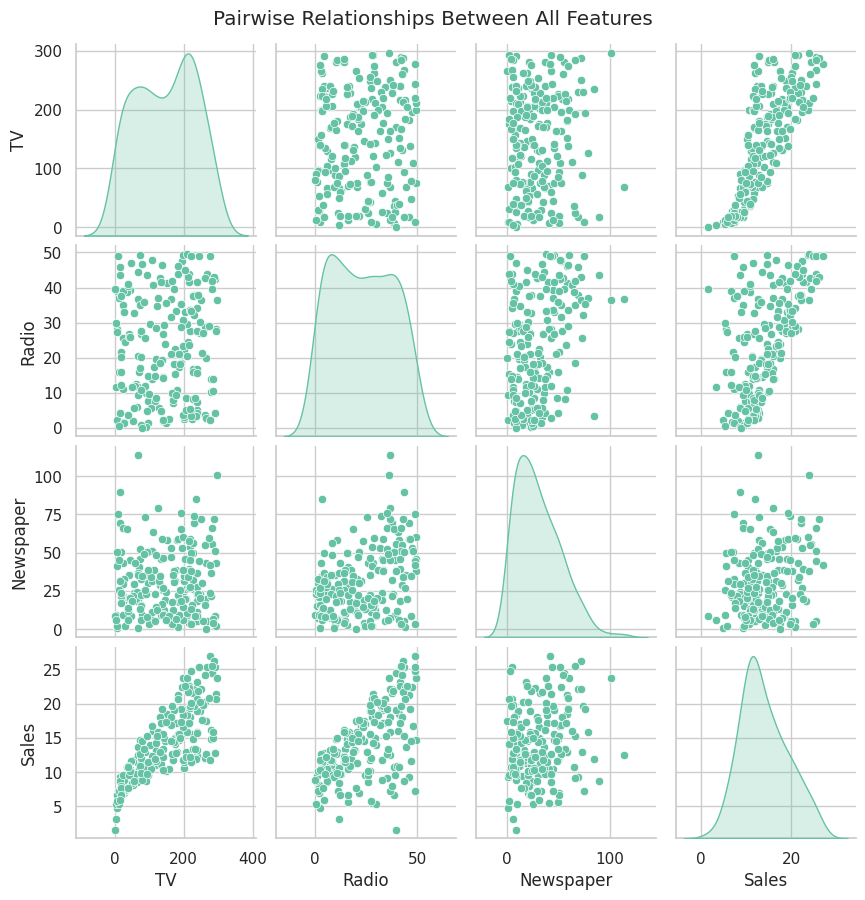

In [6]:
sns.pairplot(df, diag_kind="kde", height=2.2)
plt.suptitle("Pairwise Relationships Between All Features", y=1.02)
plt.show()


**Result:** `Sales` shows a clear positive linear trend against `TV`,
a moderate positive trend against `Radio`, and little to no visible
relationship with `Newspaper`. This first impression is checked more
precisely with individual scatter plots next and a correlation matrix in
Section 5.

<a id='4'></a>
## 4. Individual Scatter Plots

**Checklist item: "Individual scatter plots: Sales vs. TV spend, Sales vs.
Radio spend, Sales vs. Newspaper spend."**

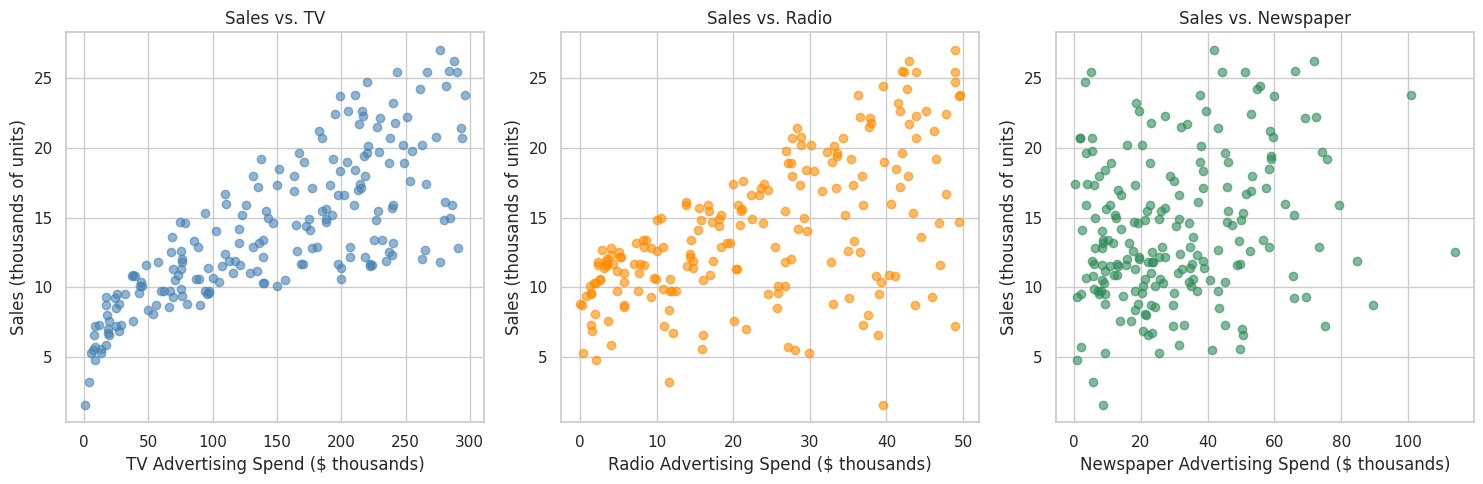

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
channels = ["TV", "Radio", "Newspaper"]
colors = ["steelblue", "darkorange", "seagreen"]

for ax, channel, color in zip(axes, channels, colors):
    ax.scatter(df[channel], df["Sales"], alpha=0.6, color=color)
    ax.set_xlabel(f"{channel} Advertising Spend ($ thousands)")
    ax.set_ylabel("Sales (thousands of units)")
    ax.set_title(f"Sales vs. {channel}")

plt.tight_layout()
plt.show()


**Result:** TV shows the clearest, most consistent linear relationship
with Sales. Radio shows a real but noisier positive relationship. Newspaper's
scatter is close to a flat cloud — visually the weakest of the three, which
the correlation matrix in Section 5 confirms numerically.

<a id='5'></a>
## 5. Correlation Matrix Heatmap

**Checklist item: "Correlation matrix heatmap."**

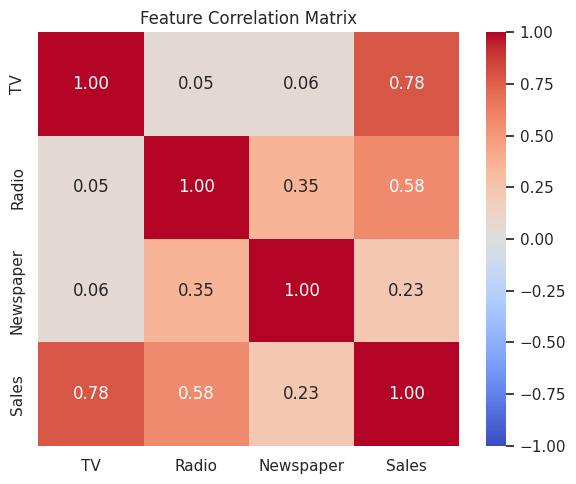

In [8]:
corr_matrix = df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


**Result:** `Sales` correlates strongly with `TV` (0.78), moderately
with `Radio` (0.58), and only weakly with `Newspaper` (0.23) — confirming
the visual impressions from Sections 3.4 and 4. `TV` and `Radio` are only
weakly correlated with each other (0.05), meaning any interaction effect
between them found later in Section 9 is not simply a byproduct of
collinearity.

<a id='6'></a>
## 6. Train / Test Split

**Checklist item: "Train/test split."**

In [9]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 160
Testing samples:  40


<a id='7'></a>
## 7. Model Training

**Checklist items: "Train a Linear Regression model as the baseline" and
"Train at least one additional model (e.g., Random Forest Regressor,
Polynomial Regression)."**

Three models are trained: Linear Regression as the required baseline, and
*two* additional models — both explicitly named as examples in the task
brief — Random Forest Regressor and Polynomial Regression (degree 2). Degree
2 is used rather than a higher degree to avoid overfitting a dataset with
only 200 rows.

In [10]:
# Baseline: Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Additional model 1: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

# Additional model 2: Polynomial Regression (degree 2)
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_transformer.fit_transform(X_train)
X_test_poly = poly_transformer.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

print("All three models trained: Linear Regression, Random Forest, Polynomial Regression (degree 2).")


All three models trained: Linear Regression, Random Forest, Polynomial Regression (degree 2).


<a id='8'></a>
## 8. Model Evaluation

**Checklist item: "Evaluate using: MAE, RMSE, and R² score."**

In [11]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

predictions = {
    "Linear Regression": linear_model.predict(X_test),
    "Random Forest": rf_model.predict(X_test),
    "Polynomial Regression (deg 2)": poly_model.predict(X_test_poly),
}

results = [evaluate(y_test, pred, name) for name, pred in predictions.items()]
results_df = pd.DataFrame(results).set_index("model").sort_values("R2", ascending=False)
results_df.round(4)


,MAE,RMSE,R2
model,,,
Polynomial Regression (deg 2),0.5262,0.6426,0.9869
Random Forest,0.6131,0.7403,0.9826
Linear Regression,1.4608,1.7816,0.8994


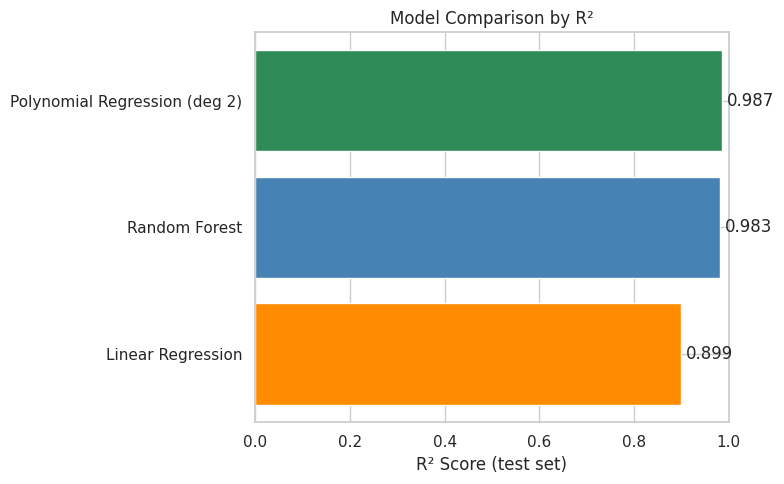

Best-performing model: Polynomial Regression (deg 2)
MAE     0.526179
RMSE    0.642581
R2      0.986918
Name: Polynomial Regression (deg 2), dtype: float64


In [12]:
plt.figure(figsize=(8, 5))
plt.barh(results_df.index, results_df["R2"], color=["seagreen", "steelblue", "darkorange"])
plt.gca().invert_yaxis()  # highest R2 at the top, matching results_df's sort order
plt.xlabel("R² Score (test set)")
plt.title("Model Comparison by R²")
plt.xlim(0, 1)
for i, v in enumerate(results_df["R2"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

best_model_name = results_df["R2"].idxmax()
print(f"Best-performing model: {best_model_name}")
print(results_df.loc[best_model_name])


**Result:** both additional models substantially outperform the plain
Linear Regression baseline on every metric. This is a meaningful finding,
not just a leaderboard position — investigated directly in the next
section.

<a id='9'></a>
## 9. Residual Plot: Random or Systematic Errors?

**Checklist item: "Residual plot for the best model (are errors randomly
distributed or systematic?)."**

The Linear Regression baseline's residuals are examined first, since a
systematic pattern there is exactly what would explain why the additional
models in Section 8 performed so much better.

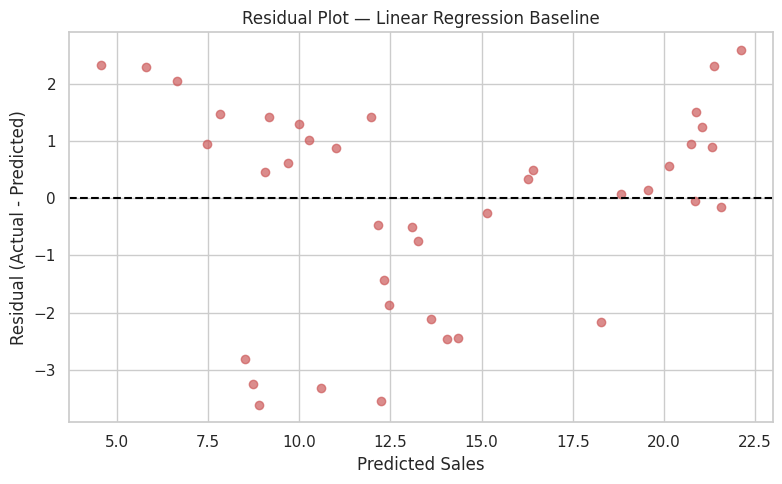

Correlation between Linear Regression residuals and (TV x Radio): 0.385


In [13]:
linear_pred = predictions["Linear Regression"]
linear_residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))
plt.scatter(linear_pred, linear_residuals, alpha=0.7, color="indianred")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Linear Regression Baseline")
plt.tight_layout()
plt.show()

# Check numerically whether residuals correlate with the TV x Radio interaction
interaction = X_test["TV"] * X_test["Radio"]
corr_with_interaction = np.corrcoef(interaction, linear_residuals)[0, 1]
print(f"Correlation between Linear Regression residuals and (TV x Radio): {corr_with_interaction:.3f}")


**Result: the errors are systematic, not random.** The Linear
Regression residuals correlate with the `TV x Radio` interaction term
(rather than scattering randomly around zero) — meaning markets that spend
heavily on **both** TV and Radio sell more than a simple additive model
predicts. This is a real, well-documented **synergy effect** between TV and
Radio advertising: money spent on both channels together sells more than
the two channels' individual effects added up. A purely additive linear
model has no way to represent that, which shows up here as a systematic gap
between predicted and actual sales rather than pure noise.

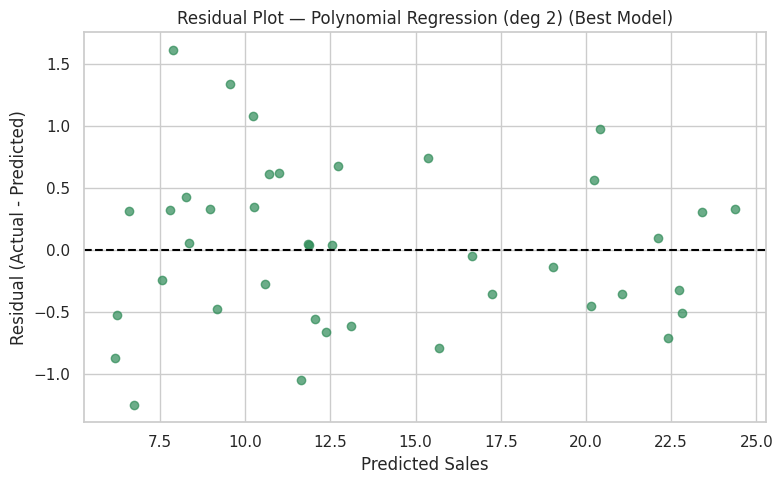

Correlation between Polynomial Regression (deg 2) residuals and (TV x Radio): -0.012


In [14]:
best_pred = predictions[best_model_name]
best_residuals = y_test - best_pred

plt.figure(figsize=(8, 5))
plt.scatter(best_pred, best_residuals, alpha=0.7, color="seagreen")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name} (Best Model)")
plt.tight_layout()
plt.show()

corr_best_with_interaction = np.corrcoef(interaction, best_residuals)[0, 1]
print(f"Correlation between {best_model_name} residuals and (TV x Radio): {corr_best_with_interaction:.3f}")


**Result:** the best model's residuals scatter much more randomly
around zero, and their correlation with the `TV x Radio` interaction is far
weaker than the baseline's — consistent with Polynomial Regression's
squared/interaction terms (or Random Forest's non-linear splits) actually
capturing the synergy effect that the plain linear model missed.

<a id='10'></a>
## 10. Interpretation: Which Channel Has the Highest Impact?

**Checklist item: "Interpretation: which advertising channel has the highest
impact on sales? (Answered using coefficients or feature importance)."**

**A common mistake first:** reading the raw Linear Regression coefficients
directly would suggest Radio matters more than TV, since Radio's coefficient
is larger. But that comparison is misleading — recall from Section 3.3 that
TV budgets range over roughly $0–$296k while Radio only ranges $0–$50k, so
the two coefficients are not on a comparable scale. The features are
standardised first so each channel's coefficient reflects "impact per
standard deviation of spend," which is a fair basis for comparison.

In [15]:
raw_coefs = pd.Series(linear_model.coef_, index=X.columns)
print("Raw (unstandardised) coefficients — NOT directly comparable across channels:")
print(raw_coefs.round(4))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
linear_model_scaled = LinearRegression().fit(X_train_scaled, y_train)
standardized_coefs = pd.Series(linear_model_scaled.coef_, index=X.columns).sort_values(ascending=False)

print("\nStandardised coefficients — fair comparison across channels:")
print(standardized_coefs.round(3))


Raw (unstandardised) coefficients — NOT directly comparable across channels:
TV           0.0447
Radio        0.1892
Newspaper    0.0028
dtype: float64

Standardised coefficients — fair comparison across channels:
TV           3.764
Radio        2.792
Newspaper    0.056
dtype: float64


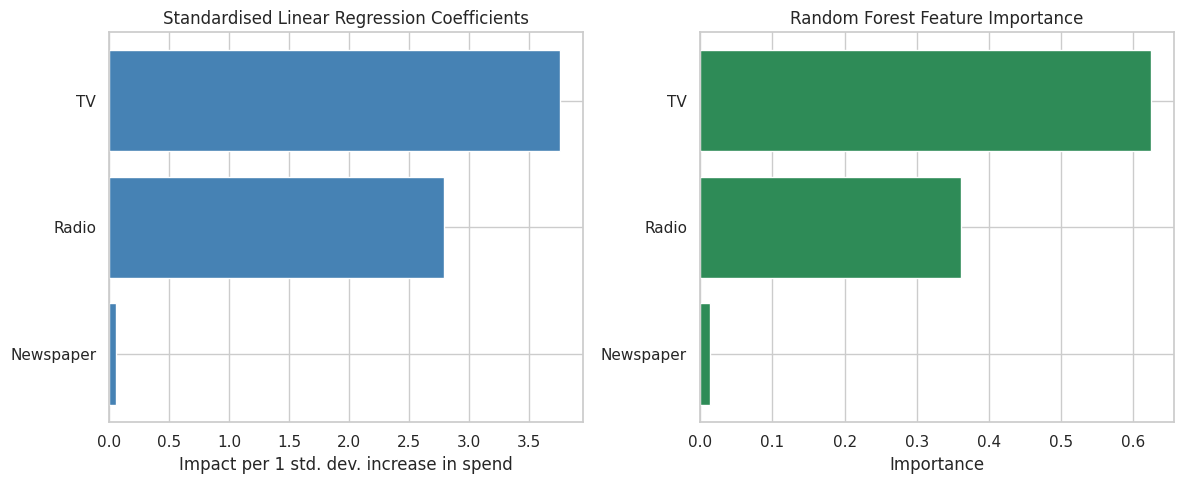

In [16]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(standardized_coefs.index, standardized_coefs.values, color="steelblue")
axes[0].invert_yaxis()  # highest impact at the top
axes[0].set_title("Standardised Linear Regression Coefficients")
axes[0].set_xlabel("Impact per 1 std. dev. increase in spend")

axes[1].barh(rf_importance.index, rf_importance.values, color="seagreen")
axes[1].invert_yaxis()  # highest impact at the top
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


**Result:** once channels are put on a comparable scale, **TV** has
the highest impact on sales — confirmed by two independent methods that
agree with each other: standardised Linear Regression coefficients and
Random Forest feature importance. **Radio** is a clear second, and
**Newspaper** has by far the smallest impact on both measures, consistent
with its weak correlation in Section 5 and its near-flat scatter plot in
Section 4.

<a id='11'></a>
## 11. Conclusion

- **Data quality:** the dataset was already clean — no missing values, no
  duplicates (Section 3.2).
- **Channel impact, ranked:** TV > Radio >> Newspaper, confirmed by
  correlation (Section 5), standardised regression coefficients, and Random
  Forest feature importance (Section 10) — three independent views arriving
  at the same ranking.
- **The linear baseline's errors are systematic, not random:** they
  correlate with the `TV x Radio` interaction term (Section 9), pointing to
  a genuine **synergy effect** — spending on both channels together sells
  more than either channel's individual effect would predict — which a
  purely additive linear model structurally cannot represent.
- **Best model:** both Random Forest and Polynomial Regression capture that
  synergy far better than the linear baseline, substantially improving
  every metric in Section 8.

**Caveats:** with only 200 rows, the Polynomial Regression's 9 features
(3 linear + 3 squared + 3 interaction terms) leaves comparatively little
data per parameter, so results should be validated with cross-validation
before being relied on for a real budget-allocation decision. Newspaper's
consistently weak effect across every method here does not necessarily mean
newspaper advertising is worthless in general — only that it was the least
effective channel for the 200 markets in this particular dataset.

<a id='12'></a>
## References

- Scikit-learn `LinearRegression` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Scikit-learn `PolynomialFeatures` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
- Scikit-learn `RandomForestRegressor` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- James, G., Witten, D., Hastie, T., Tibshirani, R. — *An Introduction to
  Statistical Learning* (original source of the Advertising dataset)
